In [12]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- Illustrator-friendly ---
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

sns.set_theme(style="white", context="paper")

# Fixed tool order you use everywhere
tool_order = ["BayesPrism", "MuSiC", "nuSVR", "CIBERSORTx", "NNLS", "QP", "ReDeconv"]

def infer_tool_from_filename(fname: str) -> str:
    """Map spillover filename -> canonical tool name."""
    f = os.path.basename(fname).lower()
    if "cibersortx" in f:
        return "CIBERSORTx"
    if "music" in f:
        return "MuSiC"
    if "nusvr" in f:
        return "nuSVR"
    if "nnls" in f:
        return "NNLS"
    if "qp" in f:
        return "QP"
    if "redeconv" in f:
        return "ReDeconv"
    if "bayesprism" in f:
        return "BayesPrism"
    return "UNKNOWN"

def load_spillover_as_long(spill_path: str) -> pd.DataFrame:
    """
    Reads one *_Spillover.txt file and returns long df:
    Tool, Matrix, CellType, Value
    Assumes first column is Matrix/Sample id and the rest are cell types.
    """
    tool = infer_tool_from_filename(spill_path)

    # Many of these are tab-delimited with wide header; engine='python' is safer
    df = pd.read_csv(spill_path, sep="\t", engine="python")

    # First column is matrix/sample id (often 'Sample' but not guaranteed)
    matrix_col = df.columns[0]
    df = df.rename(columns={matrix_col: "Matrix"})

    long = df.melt(id_vars=["Matrix"], var_name="CellType", value_name="Value")
    long["Value"] = pd.to_numeric(long["Value"], errors="coerce")
    long = long.dropna(subset=["Value"])

    long["Tool"] = tool
    return long[["Tool", "Matrix", "CellType", "Value"]]

def make_topk_heatmap_for_reference(
    ref_dir: str,
    ref_name: str,
    top_k: int = 10,
    out_svg: str | None = None
):
    """
    For one reference directory:
    - read all *_Spillover.txt
    - compute mean Value per (Tool, CellType)
    - take top_k CellTypes per Tool (by mean Value)
    - union them for x-axis
    - plot heatmap (Tool x CellType)
    """
    spill_files = sorted(glob.glob(os.path.join(ref_dir, "*_Spillover.txt")))
    if not spill_files:
        raise FileNotFoundError(f"No *_Spillover.txt found in: {ref_dir}")

    # Load all tools spillover into one long table
    all_long = []
    for fp in spill_files:
        tool = infer_tool_from_filename(fp)
        if tool == "UNKNOWN":
            continue
        all_long.append(load_spillover_as_long(fp))

    if not all_long:
        raise ValueError(f"Could not load any spillover files from: {ref_dir}")

    long_df = pd.concat(all_long, ignore_index=True)

    # Mean per (Tool, CellType)
    mean_df = (
        long_df.groupby(["Tool", "CellType"], as_index=False)["Value"]
        .mean()
        .rename(columns={"Value": "MeanValue"})
    )

    # --- Union of top_k per tool ---
    top_sets = []
    for tool in mean_df["Tool"].unique():
        tool_df = mean_df[mean_df["Tool"] == tool]
        topk = tool_df.nlargest(top_k, "MeanValue")["CellType"].tolist()
        top_sets.extend(topk)

    top_celltypes = sorted(set(top_sets))

    # Pivot: Tool x CellType
    pivot = (
        mean_df[mean_df["CellType"].isin(top_celltypes)]
        .pivot(index="Tool", columns="CellType", values="MeanValue")
    )

    # Keep tools in your preferred order, but only those present
    tools_present = [t for t in tool_order if t in pivot.index]
    pivot = pivot.loc[tools_present]

    # Column order: make columns readable by sorting by overall mean (optional, nice)
    col_order = pivot.mean(axis=0).sort_values(ascending=False).index.tolist()
    pivot = pivot[col_order]

    # Plot
    fig, ax = plt.subplots(figsize=(10, 5))   # <- SAME for all references
    fig.subplots_adjust(left=0.12, right=0.92, bottom=0.35, top=0.90)
    ax = sns.heatmap(
        pivot,
        cmap="Reds",
        annot=True,
        linewidths=0.7,
        linecolor="white",
        cbar_kws={"label": "Mean spillover / MAE (per cell type)"},
        fmt=".1f",  
        annot_kws={"size": 9}
    )

    # Axis labels
    ax.set_xlabel("Top cell types (union of top 10 per tool)")
    ax.set_ylabel("Deconvolution tool")
    plt.setp(ax.get_yticklabels(), rotation=0)

    # Colorbar label rotation 270 like your style
    cbar = ax.collections[0].colorbar
    cbar.set_label("Mean spillover / MAE (per cell type)", rotation=270, labelpad=15)

    plt.title(f"Top-{top_k} cell types by mean spillover — {ref_name}")
    plt.tight_layout()

    if out_svg:
        plt.savefig(out_svg, format="svg", bbox_inches="tight")
    plt.show()
    plt.close()

    return pivot, mean_df


/tmp/ipykernel_2443417/3077394082.py:145: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


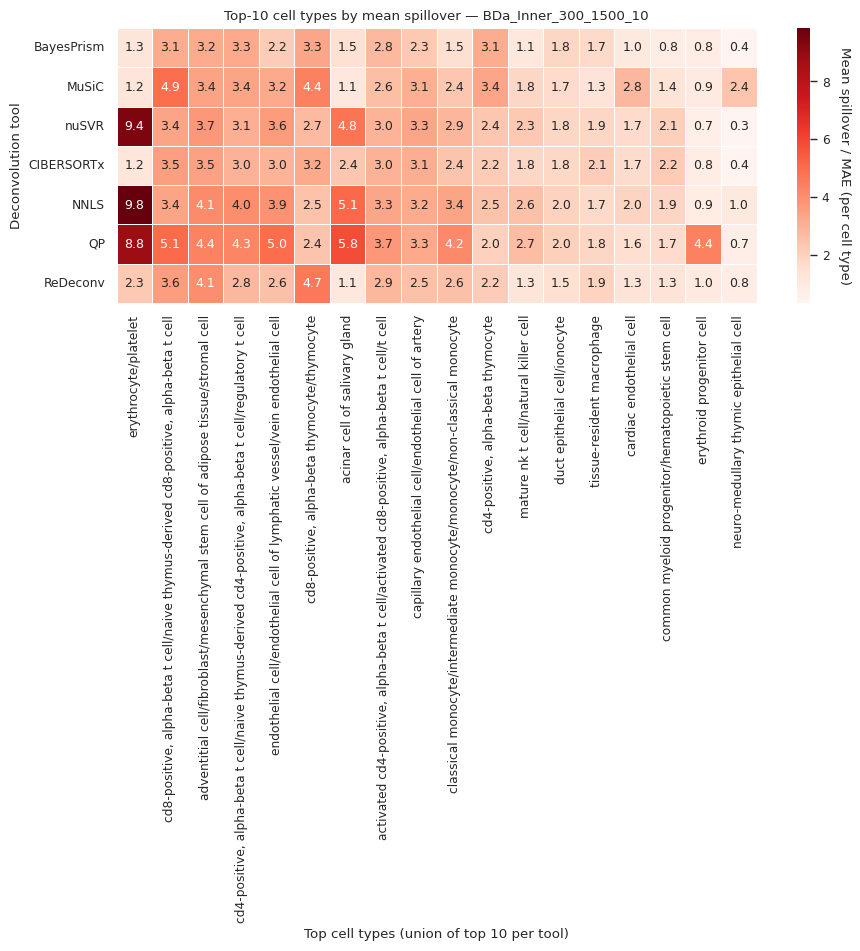

Saved: Heatmap_Top10CellTypes_BDa_Inner_300_1500_10_Spillover.svg


/tmp/ipykernel_2443417/3077394082.py:145: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


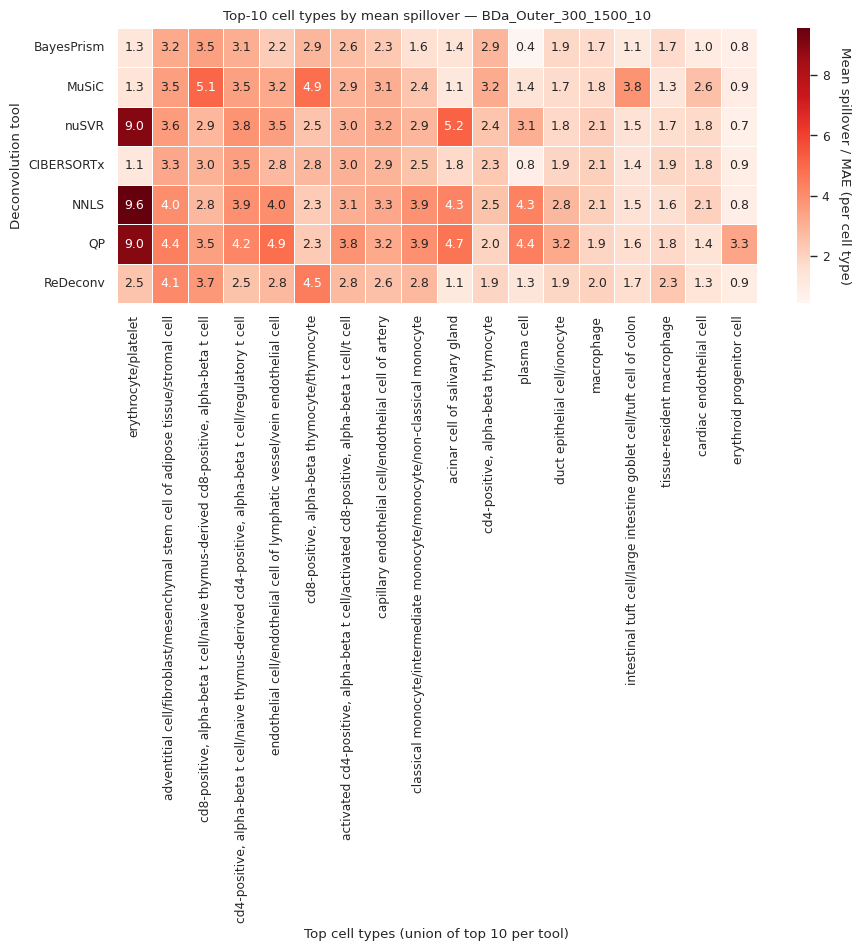

Saved: Heatmap_Top10CellTypes_BDa_Outer_300_1500_10_Spillover.svg


/tmp/ipykernel_2443417/3077394082.py:145: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


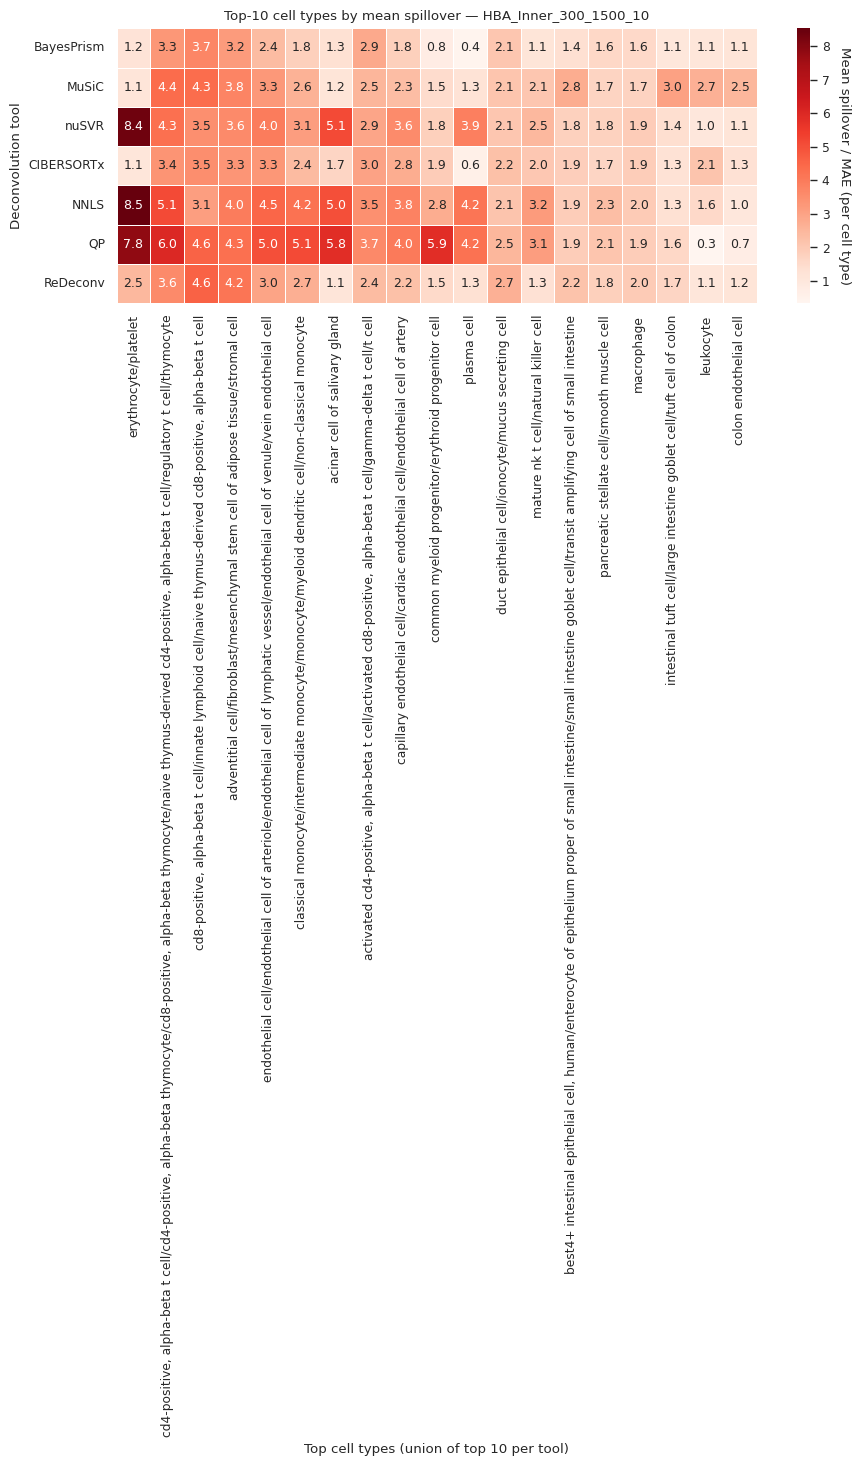

Saved: Heatmap_Top10CellTypes_HBA_Inner_300_1500_10_Spillover.svg


In [13]:
refs = [
    ("TSP-BDa_Inner_300_1500_10-Random_v2", "BDa_Inner_300_1500_10"),
    ("TSP-BDa_Outer_300_1500_10-Random_v2", "BDa_Outer_300_1500_10"),
    ("TSP-HBA_Inner_300_1500_10-Random_v2", "HBA_Inner_300_1500_10"),
]

for ref_dir, ref_name in refs:
    out_svg = f"Heatmap_Top10CellTypes_{ref_name}_Spillover.svg"
    pivot, mean_df = make_topk_heatmap_for_reference(
        ref_dir=ref_dir,
        ref_name=ref_name,
        top_k=10,
        out_svg=out_svg
    )
    print(f"Saved: {out_svg}")
